# Bài 2 – Dry Bean Dataset: Logistic Regression & K-Nearest Neighbors

**Mục tiêu:** Xây dựng và so sánh hai mô hình phân loại (7 loại hạt đậu) trên bộ dữ liệu
**Dry Bean Dataset**:

1. **Logistic Regression**
2. **K-Nearest Neighbors (KNN)**

In [24]:
# Thư viện xử lý dữ liệu
import numpy as np
import pandas as pd
from pathlib import Path

# Thư viện trực quan hóa
import matplotlib.pyplot as plt
import seaborn as sns

# Thư viện scikit-learn cho việc chia dữ liệu, chuẩn hóa và đánh giá mô hình
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler

# Hai mô hình cần xây dựng trong bài này
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

# Các chỉ số đánh giá mô hình phân loại
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

# Cấu hình hiển thị
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

RANDOM_STATE = 42  # cố định random seed để kết quả có thể tái lập (reproducible)
np.random.seed(RANDOM_STATE)
print("Đã import xong thư viện.")

Đã import xong thư viện.


---
## Task 1 — Tải dữ liệu và Khám phá ban đầu (EDA)
1. Đọc dữ liệu gốc từ `Dry_Bean_Dataset.xlsx` (`pd.read_excel`).
2. Chuẩn hóa nhãn `class` (bỏ khoảng trắng thừa, viết hoa).
3. In ra số dòng, số cột (`shape`) và thông tin kiểu dữ liệu (`.info()`).

In [25]:
DATA_DIR = Path("Dry_Bean_Dataset")
RAW_XLSX_PATH = DATA_DIR / "Dry_Bean_Dataset.xlsx"

# Biến mục tiêu
TARGET = "Class"

# Đọc dữ liệu
df = pd.read_excel(RAW_XLSX_PATH, engine = "openpyxl")

# Ép các cột số về đúng kiểu numeric
numeric_columns = [c for c in df.columns if c != TARGET]
df[numeric_columns] = df[numeric_columns].apply(pd.to_numeric, errors = "coerce")

In [26]:
# In shape và info
class_names = sorted(df[TARGET].unique())
print("Kich thuoc du lieu:", df.shape)
print("\nThong tin kieu du lieu:", df.info())

# Kiểm tra tổng missing values theo các cột
missing_value = df.isnull().sum()
print("\nSo missing value cua cac cot:\n", missing_value)

df.head()

Kich thuoc du lieu: (13611, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


---
## Task 2 — Trực quan hóa Phân phối & Tương quan
1. Vẽ biểu đồ (Countplot) thể hiện số lượng mẫu theo từng lớp (`class`) để kiểm tra dữ liệu có
   bị **mất cân bằng lớp** hay không.

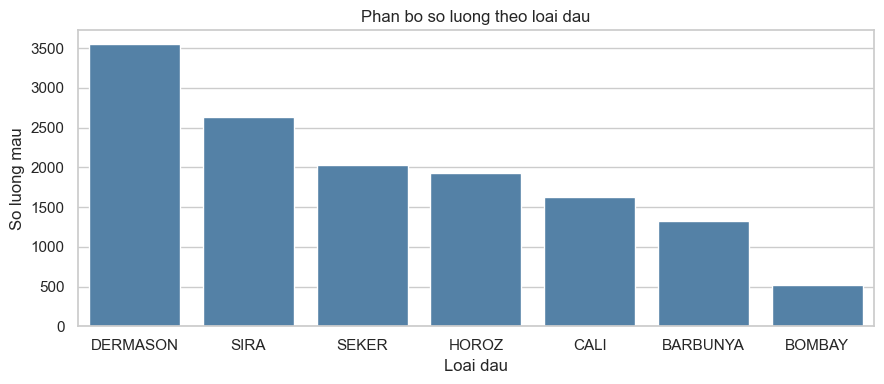

Ty le phan tram theo tung lop:
Class
BARBUNYA     9.71
BOMBAY       3.84
CALI        11.98
DERMASON    26.05
HOROZ       14.17
SEKER       14.89
SIRA        19.37
Name: proportion, dtype: float64


In [27]:
# Vẽ Countplot cho biến mục tiêu "class" - là biến phân loại với các giá trị là chữ (tên các loại đậu)
plt.figure(figsize = (9, 4))
order = df[TARGET].value_counts().index
ax = sns.countplot(data = df, x = TARGET, order = order, color = "steelblue")
ax.set_title("Phan bo so luong theo loai dau")
ax.set_xlabel("Loai dau")
ax.set_ylabel("So luong mau")
plt.tight_layout()
plt.show()

print("Ty le phan tram theo tung lop:")
print((df[TARGET].value_counts(normalize = True).sort_index() * 100).round(2))

---
## Task 3 — Chia tập dữ liệu và Tiền xử lý (Scaling)
1. Tách features (`X`) và target (`y`).
2. Chia tập Train/Test theo tỷ lệ **80/20**, dùng `stratify=y` để giữ nguyên tỉ lệ các lớp ở
   cả hai tập.
3. Dùng `StandardScaler` để scale tập `X`. Chỉ học trên tập train để tránh data leakage

In [28]:
# Chia tập và scale dữ liệu
X = df.drop(columns = TARGET)
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2,
    random_state = RANDOM_STATE,
    stratify = y,
)
print("Kich thuoc X_train:", X_train.shape)
print("Kich thuoc X_test :", X_test.shape)

# Tiền xử lý dữ liệu
scaler = StandardScaler() 
X_train_scaled = scaler.fit_transform(X_train)    # Chỉ fit trên tập train
X_test_scaled = scaler.transform(X_test)

Kich thuoc X_train: (10888, 16)
Kich thuoc X_test : (2723, 16)


---
## Task 4 — Hàm hỗ trợ đánh giá mô hình

Để tránh lặp lại code khi đánh giá hai mô hình, ta viết một hàm dùng chung: tính accuracy,
precision/recall/f1 (theo cách tính `macro average` – tính trung bình không trọng số qua 7
lớp, phù hợp vì đây là bài toán multi-class), in `classification_report` chi tiết theo từng
lớp, và vẽ confusion matrix.

In [29]:
# Hàm đánh giá mô hình
def evaluate_model(model_name, y_true, y_pred, class_labels):
    # Tính giá trị của các metric vs y_true và y_pred
    # Có 7 class, ở đây ta dùng average = "macro"
    accuracy = accuracy_score(y_true, y_pred)
    precision_macro = precision_score(y_true, y_pred, average = "macro", zero_division = 0)
    recall_macro = recall_score(y_true, y_pred, average = "macro", zero_division = 0)
    f1_macro = f1_score(y_true, y_pred, average = "macro", zero_division = 0)

    print(f"Kết quả đánh giá: {model_name}")
    print(f"Accuracy           : {accuracy:.4f}")
    print(f"Precision (macro)  : {precision_macro:.4f}")
    print(f"Recall (macro)     : {recall_macro:.4f}")
    print(f"F1-score (macro)   : {f1_macro:.4f}")

    print("\nBao cao chi tiet theo tung lop:")
    print(classification_report(y_true, y_pred, digits = 4, zero_division = 0))

    # Vẽ confusion matrix
    cm = confusion_matrix(y_true, y_pred, labels=class_labels)
    fig, ax = plt.subplots(figsize = (7, 6))
    cf_matrix = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = class_labels)
    cf_matrix.plot(ax = ax, cmap = "Blues", colorbar = False)
    ax.set_title(f"Confusion Matrix - {model_name}")
    plt.tight_layout()
    plt.show()

    return {
        "model": model_name,
        "accuracy": accuracy,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
    }


results = []  # danh sách lưu kết quả của từng mô hình để so sánh ở cuối notebook

---
## Task 5 — Huấn luyện Logistic Regression
1. Khởi tạo và huấn luyện mô hình `LogisticRegression` trên tập Train đã scale.
2. Dự đoán trên tập Test.
3. Đánh giá bằng hàm `evaluate_model`.

Kết quả đánh giá: Logistic Regression
Accuracy           : 0.9214
Precision (macro)  : 0.9354
Recall (macro)     : 0.9321
F1-score (macro)   : 0.9335

Bao cao chi tiet theo tung lop:
              precision    recall  f1-score   support

    BARBUNYA     0.9516    0.8906    0.9201       265
      BOMBAY     1.0000    1.0000    1.0000       104
        CALI     0.9303    0.9417    0.9360       326
    DERMASON     0.9240    0.9083    0.9161       709
       HOROZ     0.9633    0.9508    0.9570       386
       SEKER     0.9303    0.9532    0.9416       406
        SIRA     0.8483    0.8805    0.8641       527

    accuracy                         0.9214      2723
   macro avg     0.9354    0.9321    0.9335      2723
weighted avg     0.9222    0.9214    0.9216      2723



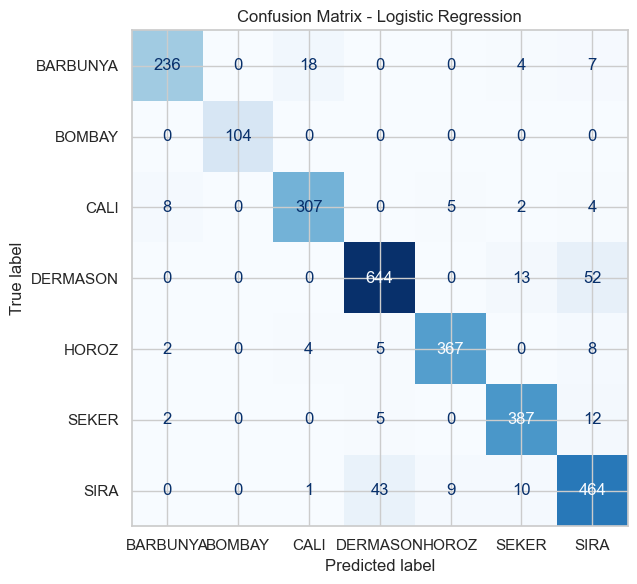

In [30]:
# Huấn luyện và Đánh giá Logistic Regression
log_model = LogisticRegression(max_iter = 1000, random_state = RANDOM_STATE)

log_model.fit(X_train_scaled , y_train)

y_pred_log = log_model.predict(X_test_scaled)

# Đánh giá mô hình
log_result = evaluate_model(
    model_name = "Logistic Regression",
    y_true = y_test,
    y_pred = y_pred_log,
    class_labels = class_names,
)
results.append(log_result)

---
## Task 6 — Huấn luyện K-Nearest Neighbors (KNN)

### 6.1. Chọn số láng giềng K phù hợp
KNN có một siêu tham số (hyperparameter) quan trọng là **K** – số láng giềng gần nhất được xét khi dự đoán.
> Dùng **5-fold cross-validation trên tập train** (giống cách **GridSearchCV** được dùng để tìm **alpha** tối ưu cho Ridge Regression) để thử nhiều giá trị K khác nhau, rồi chọn K cho accuracy trung bình cao nhất.

In [31]:
# Tìm K tối ưu bằng 5-fold Cross-Validation
K_value = range(1 , 31)  # thử K từ 1 đến 30
accuracies = []

for K in K_value:
    KNN_model = KNeighborsClassifier(n_neighbors = K)
    cv_scores = cross_val_score(
        KNN_model,            # estimator
        X_train_scaled,
        y_train,
        cv = 5,               # Số phần dữ liệu được chia để hoán đổi giữa huấn luyện và chạy test
        scoring = "f1_macro", # metric đánh giá
    )
    accuracies.append(cv_scores.mean())
    print(f"K = {K:2d} -> F1_score trung binh = {cv_scores.mean():.4f}")

best_k = list(K_value)[int(np.argmax(accuracies))]
print(f"\n>>> K tot nhat co the chon: {best_k}")

K =  1 -> F1_score trung binh = 0.9208
K =  2 -> F1_score trung binh = 0.9167
K =  3 -> F1_score trung binh = 0.9307
K =  4 -> F1_score trung binh = 0.9332
K =  5 -> F1_score trung binh = 0.9336
K =  6 -> F1_score trung binh = 0.9342
K =  7 -> F1_score trung binh = 0.9357
K =  8 -> F1_score trung binh = 0.9350
K =  9 -> F1_score trung binh = 0.9363
K = 10 -> F1_score trung binh = 0.9362
K = 11 -> F1_score trung binh = 0.9355
K = 12 -> F1_score trung binh = 0.9345
K = 13 -> F1_score trung binh = 0.9360
K = 14 -> F1_score trung binh = 0.9356
K = 15 -> F1_score trung binh = 0.9357
K = 16 -> F1_score trung binh = 0.9364
K = 17 -> F1_score trung binh = 0.9365
K = 18 -> F1_score trung binh = 0.9363
K = 19 -> F1_score trung binh = 0.9370
K = 20 -> F1_score trung binh = 0.9374
K = 21 -> F1_score trung binh = 0.9379
K = 22 -> F1_score trung binh = 0.9369
K = 23 -> F1_score trung binh = 0.9364
K = 24 -> F1_score trung binh = 0.9364
K = 25 -> F1_score trung binh = 0.9362
K = 26 -> F1_score trung 

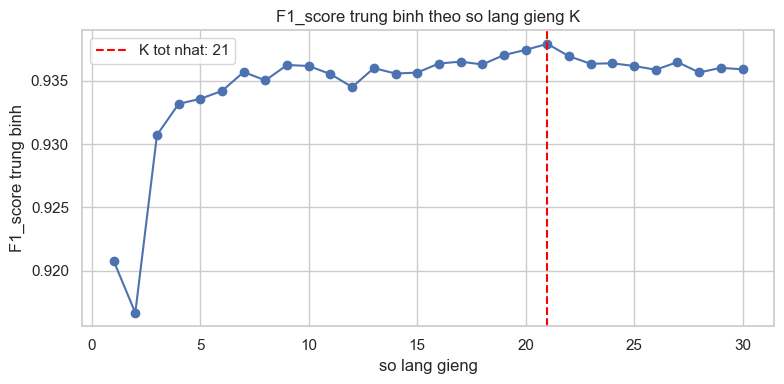

In [32]:
fig, ax = plt.subplots(figsize = (8, 4))
ax.plot(list(K_value), accuracies, marker = "o")
ax.axvline(best_k, color = "red", linestyle = "--", label = f"K tot nhat: {best_k}")
ax.set_title("F1_score trung binh theo so lang gieng K")
ax.set_xlabel("so lang gieng")
ax.set_ylabel("F1_score trung binh")
ax.legend()
plt.tight_layout()
plt.show()

### 6.2. Huấn luyện KNN với K tốt nhất

In [33]:
# Cài đặt mô hình KNN với K tốt nhất
knn_model_best = KNeighborsClassifier(n_neighbors = best_k)
knn_model_best.fit(X_train_scaled, y_train)

# Cho mô hình chạy thử trên tập test
y_pred_knn = knn_model_best.predict(X_test_scaled)

### 6.3. Đánh giá KNN

Kết quả đánh giá: KNN model(K = 21)
Accuracy           : 0.9188
Precision (macro)  : 0.9348
Recall (macro)     : 0.9294
F1-score (macro)   : 0.9316

Bao cao chi tiet theo tung lop:
              precision    recall  f1-score   support

    BARBUNYA     0.9706    0.8717    0.9185       265
      BOMBAY     1.0000    1.0000    1.0000       104
        CALI     0.9179    0.9601    0.9385       326
    DERMASON     0.9161    0.9083    0.9122       709
       HOROZ     0.9580    0.9456    0.9518       386
       SEKER     0.9364    0.9433    0.9399       406
        SIRA     0.8446    0.8767    0.8603       527

    accuracy                         0.9188      2723
   macro avg     0.9348    0.9294    0.9316      2723
weighted avg     0.9199    0.9188    0.9190      2723



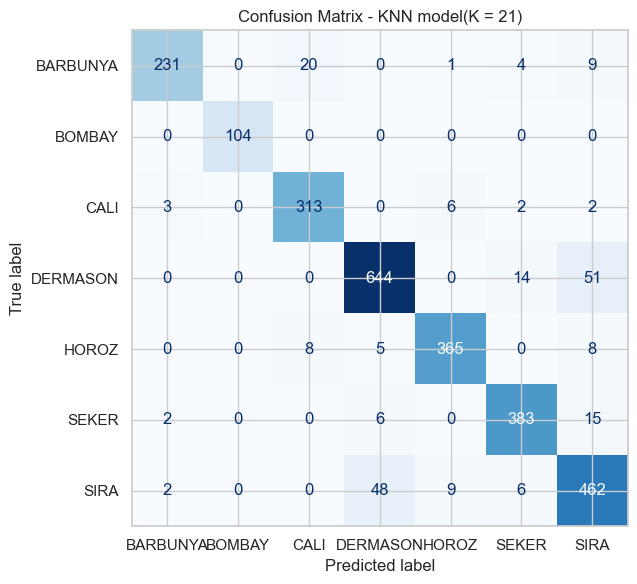

In [34]:
knn_result = evaluate_model(
    model_name = f"KNN model(K = {best_k})",
    y_true = y_test,
    y_pred = y_pred_knn,
    class_labels = class_names,
)
results.append(knn_result)

---
## Task 7 — So sánh hai mô hình và Kết luận

In [35]:
comparison_df = pd.DataFrame(results).set_index("model")
comparison_df = comparison_df.round(4)
display(comparison_df)

best_model = comparison_df["f1_macro"].idxmax()
print(f"\n>>> Mo hinh co F1 cao hon: {best_model}")

,accuracy,precision_macro,recall_macro,f1_macro
model,,,,
Logistic Regression,0.9214,0.9354,0.9321,0.9335
KNN model(K = 21),0.9188,0.9348,0.9294,0.9316



>>> Mo hinh co F1 cao hon: Logistic Regression


### Nhận xét & kết luận
1. Mô hình **Logistic Regression** có giá trị **F1_score** cao hơn so với mô hình **KNN**.
2. Mô hình **KNN** phụ thuộc vào việc lưu toàn bộ tập train để so sánh khoảng cách khi dự đoán, nên thường dự đoán chậm hơn **Logistic Regression** khi dữ liệu lớn; trong khi **Logistic Regression** chỉ cần một bộ trọng số (weights) đã học nên dự đoán rất nhanh.
3. **Logistic Regression** giả định ranh giới giữa các lớp có thể xấp xỉ tuyến tính (trong không gian sau scale), trong khi KNN không giả định gì về dạng ranh giới, nên có thể linh hoạt hơn với dữ liệu có ranh giới phức tạp, đổi lại nhạy cảm hơn với nhiễu và tốn chi phí tính toán khi dự đoán.